### Registered Agents

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
RegisAgents_df = pd.read_csv("../Datasets/Registered_Agents.csv")

In [3]:
RegisAgents_df.head()

,Date,Clean Date,Northern Africa,Eastern Africa,Southern Africa,Western Africa,Sub-Saharan Africa,Southern Africa.1,Western Africa.1,Sub-Saharan Africa.1
0,Dec-11,12/01/11,1203,151278,126417,1458,1203,2074,20126,150075
1,Mar-12,03/01/12,1197,193515,161508,2270,1197,2227,26314,192318
2,Jun-12,06/01/12,2097,233186,191223,5226,2097,2376,32264,231089
3,Sep-12,09/01/12,2401,302222,239790,17715,2401,5109,37207,299821
4,Dec-12,12/01/12,2515,368043,269440,26692,2515,9054,60342,365529


In [4]:
RegisAgents_df.tail()

,Date,Clean Date,Northern Africa,Eastern Africa,Southern Africa,Western Africa,Sub-Saharan Africa,Southern Africa.1,Western Africa.1,Sub-Saharan Africa.1
48,Dec-23,12/01/23,374476,13847121,4073911,1815005,374476,128210,7455520,13472646
49,Mar-24,03/01/24,376656,14674322,4366463,1836934,376656,131878,7962391,14297666
50,Jun-24,06/01/24,379276,15484957,4764571,1984755,379276,137664,8218691,15105681
51,Sep-24,09/01/24,387040,16407447,5068942,2157708,387040,144840,8648916,16020406
52,Dec-24,12/01/24,391555,17370755,5413439,2321010,391555,152885,9091866,16979200


In [5]:
RegisAgents_df.shape

(53, 10)

In [6]:
RegisAgents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  53 non-null     object
 1   Clean Date            53 non-null     object
 2   Northern Africa       53 non-null     int64 
 3   Eastern Africa        53 non-null     int64 
 4   Southern Africa       53 non-null     int64 
 5   Western Africa        53 non-null     int64 
 6   Sub-Saharan Africa    53 non-null     int64 
 7   Southern Africa.1     53 non-null     int64 
 8   Western Africa.1      53 non-null     int64 
 9   Sub-Saharan Africa.1  53 non-null     int64 
dtypes: int64(8), object(2)
memory usage: 4.3+ KB


In [7]:
RegisAgents_df.isnull().sum()

Date                    0
Clean Date              0
Northern Africa         0
Eastern Africa          0
Southern Africa         0
Western Africa          0
Sub-Saharan Africa      0
Southern Africa.1       0
Western Africa.1        0
Sub-Saharan Africa.1    0
dtype: int64

In [8]:
#Converting all columns names to lowercase
RegisAgents_df.columns = RegisAgents_df.columns.str.lower()

# Remove leading/trailing spaces and replace internal spaces with underscores
RegisAgents_df.columns = RegisAgents_df.columns.str.strip().str.replace(' ', '_')

print(RegisAgents_df.columns.tolist())

['date', 'clean_date', 'northern_africa', 'eastern_africa', 'southern_africa', 'western_africa', 'sub-saharan_africa', 'southern_africa.1', 'western_africa.1', 'sub-saharan_africa.1']


In [9]:
# Converting Clean date from object to date.
RegisAgents_df["clean_date"] = pd.to_datetime(RegisAgents_df["clean_date"])

/tmp/ipykernel_4265/2622515917.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  RegisAgents_df["clean_date"] = pd.to_datetime(RegisAgents_df["clean_date"])


In [10]:
RegisAgents_df["clean_date"].head()

0   2011-12-01
1   2012-03-01
2   2012-06-01
3   2012-09-01
4   2012-12-01
Name: clean_date, dtype: datetime64[ns]

In [11]:
# Display statistical summary of all the numerical columns transposed
RegisAgents_df.describe().T

,count,mean,min,25%,50%,75%,max,std
clean_date,53,2018-06-01 05:53:12.452830208,2011-12-01 00:00:00,2015-03-01 00:00:00,2018-06-01 00:00:00,2021-09-01 00:00:00,2024-12-01 00:00:00,NaN
northern_africa,53.0,132039.679245,1197.0,32880.0,80017.0,136363.0,391555.0,130988.477693
eastern_africa,53.0,4449694.716981,151278.0,1035295.0,2516700.0,6243075.0,17370755.0,4650970.506072
southern_africa,53.0,1677673.396226,126417.0,606317.0,1305620.0,2508345.0,5413439.0,1363041.924023
western_africa,53.0,620196.54717,1458.0,144891.0,356930.0,1033439.0,2321010.0,623565.459033
sub-saharan_africa,53.0,132039.679245,1197.0,32880.0,80017.0,136363.0,391555.0,130988.477693
southern_africa.1,53.0,52769.377358,2074.0,23901.0,34141.0,83541.0,152885.0,43328.470911
western_africa.1,53.0,1967015.943396,20126.0,224146.0,759787.0,2544822.0,9091866.0,2529708.432176
sub-saharan_africa.1,53.0,4317655.113208,150075.0,1002415.0,2450556.0,6106712.0,16979200.0,4527846.73784


In [13]:
Registered_Agents_Dec_raw = RegisAgents_df[RegisAgents_df["clean_date"].dt.month == 12].copy()

In [14]:
# Extracting the year from the clean date column
# (Errors='coerce' handles any messy strings safely)
Registered_Agents_Dec_raw["Year"] = pd.to_datetime(Registered_Agents_Dec_raw["clean_date"]).dt.year

In [17]:
Registered_Agents_Dec = Registered_Agents_Dec_raw.melt(
    id_vars=["date", "clean_date"], # date and clean_date are preserved
    value_vars=[
        "northern_africa",
        "eastern_africa",
        "southern_africa",
        "western_africa",
        "sub-saharan_africa"
    ],
    var_name="Region",
    value_name="Value"
)

In [18]:
Registered_Agents_Dec["Value"] = pd.to_numeric(Registered_Agents_Dec["Value"])

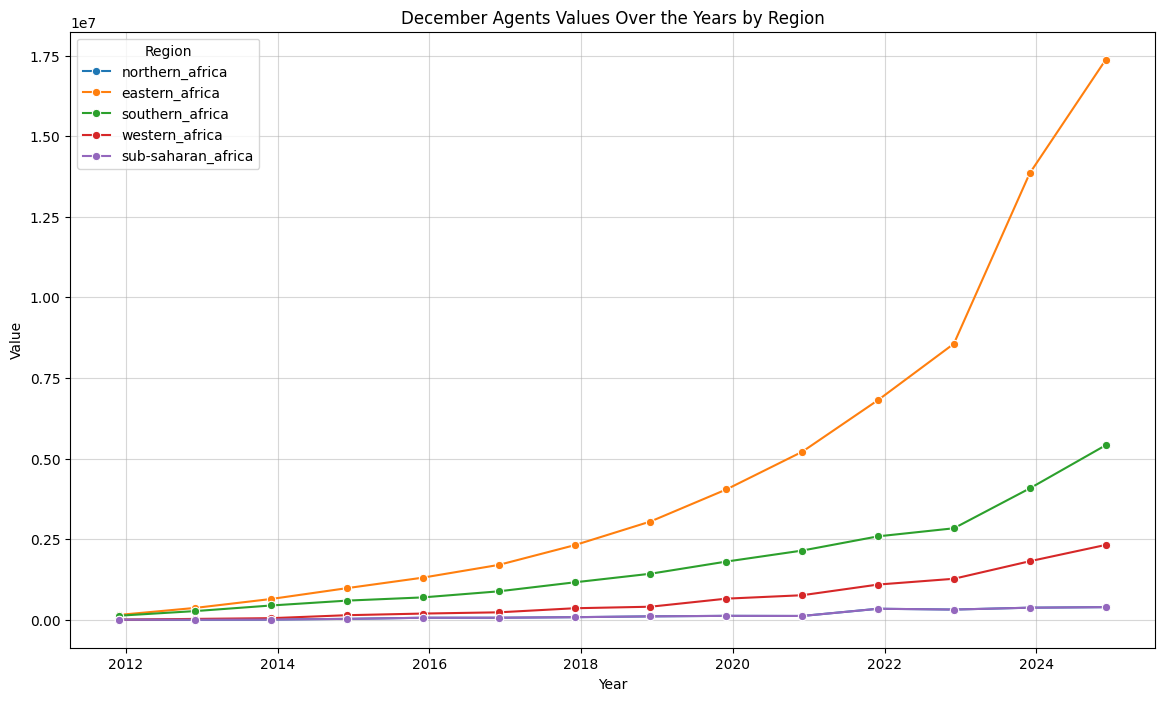

In [19]:
# 3. Plot using "date" as your X-axis
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=Registered_Agents_Dec,
    x="clean_date",          # Using 'date' directly since it represents the years
    y="Value",
    hue="Region",
    marker="o"
)

plt.title("December Agents Values Over the Years by Region")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True, linestyle="-", alpha=0.5)

plt.show()